## Элементарные методы анализа временных рядов: MA, EMA, DEMA и TEMA

Два ряда из папки `Series`: ежедневные рождения девочек в Калифорнии за 1959 год (365 точек)
и помесячный поток пассажиров международных авиалиний за 1949-1960 годы (144 точки). Первый
тест Дики-Фуллера признает стационарным, второй за двенадцать лет вырастает со 104 тысяч
пассажиров в месяц до 622 и стационарным не является.

На каждом из них сравниваются четыре модели сглаживания: скользящее среднее **MA**,
экспоненциальное сглаживание **EMA**, двойное **DEMA** и тройное **TEMA**. Параметры каждой
подбираются на ранней части ряда, прогноз строится на отложенный последний период, качество
меряется **RMSE** и **MAE** по фактическим значениям этого периода

### Задача 1. Два ряда: стационарный и нестационарный

Задание требует пары рядов с разными свойствами, и выбирать их на глаз не хочется: «выглядит
ровным» - не проверка. Стационарность смотрится тремя способами сразу, потому что каждый
по отдельности обманывает.

Тест **Дики-Фуллера** ищет единичный корень, то есть накопительный тренд, и его нулевая гипотеза -
нестационарность. Тест **KPSS** устроен зеркально: в нулевой гипотезе у него стационарность.
**Метод интервалов** ни на какую гипотезу не опирается - ряд режется на четыре куска, и у
стационарного ряда среднее с разбросом от куска к куску не меняются

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning

# statsmodels при импорте ставит свои фильтры в начало списка, а выигрывает первый подошедший.
# поэтому глушить предупреждения надо после импорта, а не до - иначе его собственные проходят
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')


def месячный(файл, значение):
    df = pd.read_csv(файл)
    ряд = df[значение].astype(float)
    ряд.index = pd.PeriodIndex(df.iloc[:, 0], freq='M').to_timestamp()
    return ряд


def дневной(файл, значение):
    df = pd.read_csv(файл)
    ряд = df[значение].astype(float)
    ряд.index = pd.to_datetime(df.iloc[:, 0])
    return ряд


РЯДЫ = {
    'Рождения девочек': дневной('daily-total-female-births-in-cal.csv', 'Count'),
    'Пассажиры авиалиний': месячный('international-airline-passengers.csv', 'Count'),
}


def kpss_p(x):
    """KPSS берет p-value из таблицы и за ее краями возвращает граничное значение,
    а не настоящее. Ловим это, чтобы в таблице стояло «<0.01»: иначе край таблицы
    читается как посчитанное число"""
    with warnings.catch_warnings(record=True) as поймано:
        warnings.simplefilter('always')
        p = kpss(x, regression='c', nlags='auto')[1]
    за_краем = any(issubclass(п.category, InterpolationWarning) for п in поймано)
    if not за_краем:
        return f'{p:.4f}'
    return f'<{p:g}' if p <= 0.01 else f'>{p:g}'


опись = []
for имя, ряд in РЯДЫ.items():
    p_adf = adfuller(ряд, autolag='BIC')[1]
    p_kpss = kpss_p(ряд)
    опись.append({'ряд': имя, 'точек': len(ряд), 'шаг': 'день' if len(ряд) > 200 else 'месяц',
                  'начало': ряд.index[0].date(), 'конец': ряд.index[-1].date(),
                  'минимум': ряд.min(), 'максимум': ряд.max(),
                  'среднее': round(ряд.mean(), 1), 'разброс': round(ряд.std(), 2),
                  'ADF p-value': round(p_adf, 4), 'KPSS p-value': p_kpss})

print(pd.DataFrame(опись).to_string(index=False))


def интервалы(x, имя):
    """метод интервалов: у стационарного ряда среднее и разброс не зависят от куска"""
    куски = np.array_split(pd.Series(x).dropna().values, 4)
    строка = {'ряд': имя}
    for i, к in enumerate(куски, 1):
        строка[f'среднее {i}'] = round(float(к.mean()), 2)
    for i, к in enumerate(куски, 1):
        строка[f'разброс {i}'] = round(float(к.std(ddof=1)), 2)
    return строка


print('\nметод интервалов, ряд разрезан на четыре равные части:')
print(pd.DataFrame([интервалы(ряд, имя) for имя, ряд in РЯДЫ.items()]).to_string(index=False))

                ряд  точек   шаг     начало      конец  минимум  максимум  среднее  разброс  ADF p-value KPSS p-value
   Рождения девочек    365  день 1959-01-01 1959-12-31     23.0      73.0     42.0     7.35       0.0000        <0.01
Пассажиры авиалиний    144 месяц 1949-01-01 1960-12-01    104.0     622.0    280.3   119.97       0.9919        <0.01

метод интервалов, ряд разрезан на четыре равные части:
                ряд  среднее 1  среднее 2  среднее 3  среднее 4  разброс 1  разброс 2  разброс 3  разброс 4
   Рождения девочек      39.77      39.81      44.59      43.77       7.41       6.66       7.57       6.43
Пассажиры авиалиний     145.50     220.31     326.89     428.50      24.94      33.41      59.61      79.33


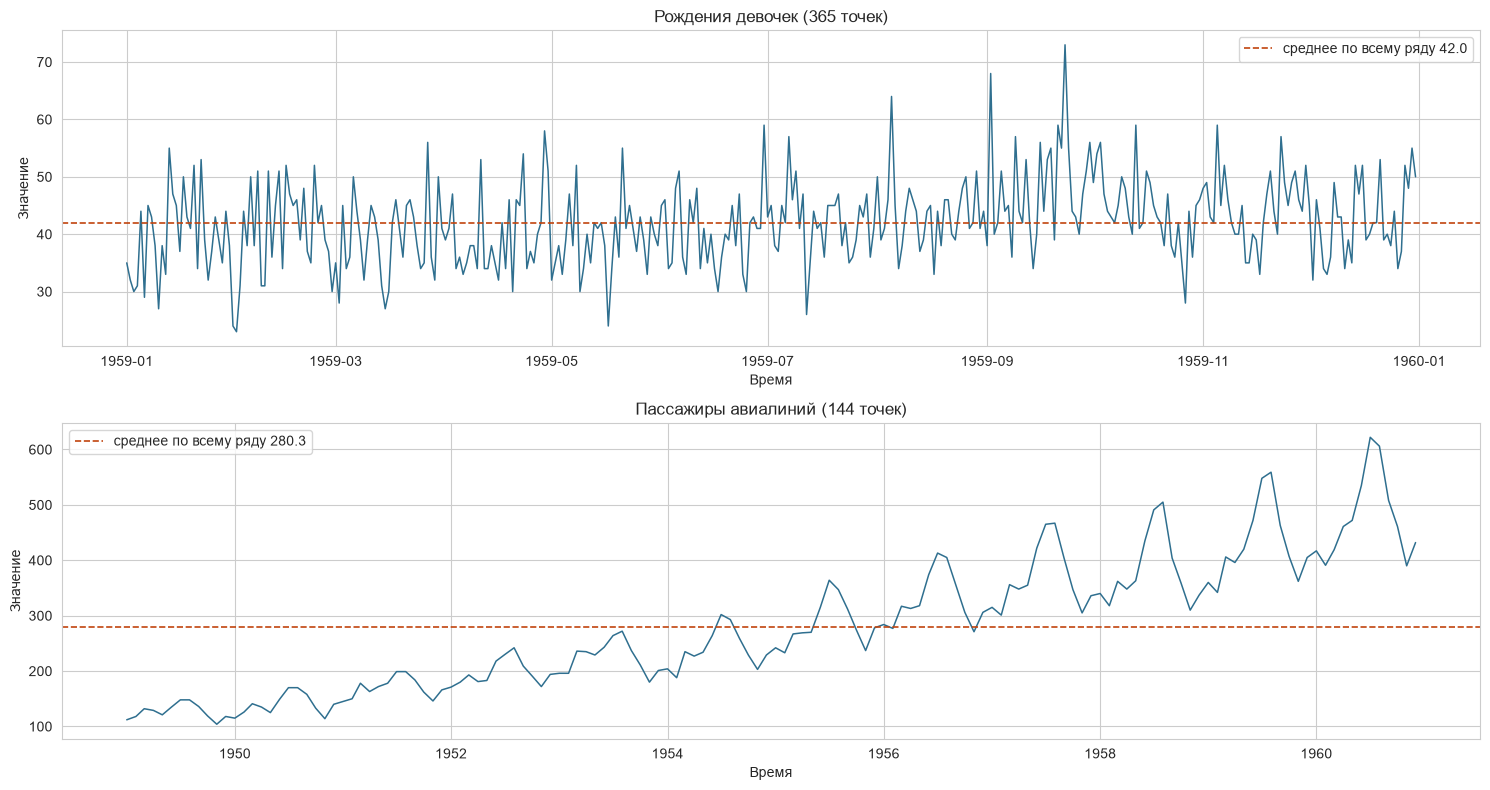

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
for ось, (имя, ряд) in zip(axes, РЯДЫ.items()):
    ось.plot(ряд.index, ряд.values, color='#2f6f8f', linewidth=1.1)
    ось.axhline(ряд.mean(), color='#c1440e', linestyle='--', linewidth=1.2,
                label=f'среднее по всему ряду {ряд.mean():.1f}')
    ось.set_title(f'{имя} ({len(ряд)} точек)')
    ось.set_xlabel('Время')
    ось.set_ylabel('Значение')
    ось.legend()
plt.tight_layout()
plt.show()

**Вывод по Задаче 1:**

**Ряды выбраны так, что расходятся по всем трем проверкам сразу.**

*   **Рождения девочек.** Тест Дики-Фуллера дает p-value **0.0000** - единичного корня нет,
    накопительного тренда в ряде не заводится. На графике это шум вокруг сорока двух рождений
    в день: линия среднего проходит сквозь ряд, а не под ним и не над ним.
*   **Пассажиры авиалиний.** p-value **0.9919**, то есть тест не нашел ни малейшего основания
    отвергнуть нестационарность. Поток идет от минимума в **104** тысячи пассажиров в месяц
    к максимуму в **622**, линия общего среднего лежит поперек ряда и не описывает ни одного
    его участка. Летние пики становятся выше вместе с уровнем потока.

**Метод интервалов добавляет к этому важную оговорку про рождения.** Средние по четырем кускам
идут **39.77, 39.81, 44.59, 43.77**: во второй половине года рождений в день примерно на четыре
больше, чем в первой. KPSS, у которого в нулевой гипотезе стоит стационарность, этот сдвиг ловит -
его p-value **ниже 0.01**, то есть стационарность он отвергает. В таблице стоит именно «<0.01»,
а не число: 0.01 - нижний край таблицы, из которой тест берет p-value, и дальше точного значения
он не дает. Разбросы при этом стоят на месте (7.41, 6.66, 7.57, 6.43).

Итого стационарность у рождений неполная: **среднее гуляет, дисперсия постоянна**. Для задания
это скорее плюс - будет видно, дотянется ли до такого сдвига модель с трендом. У пассажиров
согласия нет вообще: там оба теста и метод интервалов говорят одно и то же, средние по кускам
**145.5, 220.3, 326.9, 428.5**, разбросы **24.9, 33.4, 59.6, 79.3** - за уровнем растет и размах

### Задача 2. Разметка выборок, горизонт и метрика

Задание задает порядок прямо: параметры подбираются на ранней части ряда, прогноз строится
на последний период, и он сравнивается с истинными значениями. Значит, ряд режется **по времени**
на три куска подряд.

*   **Обучение** - по нему модель набирает уровень, тренд и сезонный профиль.
*   **Проверка** - на ней перебираются параметры. Это будущее по отношению к обучению, поэтому
    подбор идет по настоящему прогнозу, а не по подгонке к уже виденным точкам.
*   **Тест** - последний период ряда. Он не участвует ни в обучении, ни в подборе и вскрывается
    один раз в самом конце.

Длина проверки взята равной длине теста: параметры должны подбираться под тот же горизонт,
на котором их потом спросят. Для пассажиров это 12 месяцев, для рождений - 28 дней, то есть
четыре полные недели.

TEMA нужен период сезона, и брать его из общих соображений нельзя - это выбор по данным. Берем
его по автокорреляции **обучающей части**: тестовый и проверочный отрезки в этот момент еще
закрыты

In [3]:
ГОРИЗОНТ = {'Рождения девочек': 28, 'Пассажиры авиалиний': 12}

# ряд режется по времени: обучение -> проверка -> тест, тест это самый хвост
ВЫБОРКИ = {}
for имя, ряд in РЯДЫ.items():
    h = ГОРИЗОНТ[имя]
    ВЫБОРКИ[имя] = {'обучение': ряд[:-2 * h], 'проверка': ряд[-2 * h:-h],
                    'до теста': ряд[:-h], 'тест': ряд[-h:]}

разметка = [{'ряд': имя, 'обучение': len(в['обучение']), 'проверка': len(в['проверка']),
             'тест': len(в['тест']), 'горизонт': ГОРИЗОНТ[имя],
             'тест начинается': в['тест'].index[0].date()}
            for имя, в in ВЫБОРКИ.items()]
print(pd.DataFrame(разметка).to_string(index=False))

# период сезона определяется по обучающей части: проверка и тест на этом шаге еще закрыты
print('\nавтокорреляция обучающей части, значимые лаги до 30:')
СЕЗОН = {}
for имя, в in ВЫБОРКИ.items():
    а = acf(в['обучение'], nlags=30)
    порог = 2 / np.sqrt(len(в['обучение']))
    значимые = [i for i in range(1, 31) if abs(а[i]) > порог]
    СЕЗОН[имя] = 7 if имя == 'Рождения девочек' else 12
    print(f'  {имя}: порог {порог:.3f}, значимые лаги {значимые}')
    print(f'     ACF по лагам 1-14: ' + ' '.join(f'{i}:{а[i]:.3f}' for i in range(1, 15)))
    print(f'     ACF({СЕЗОН[имя]}) = {а[СЕЗОН[имя]]:.3f}, взятый период сезона {СЕЗОН[имя]}')

# у дневного ряда сезон недельный, и он же виден напрямую как профиль дня недели
об = ВЫБОРКИ['Рождения девочек']['обучение']
дни = ['понедельник', 'вторник', 'среда', 'четверг', 'пятница', 'суббота', 'воскресенье']
профиль = об.groupby(об.index.dayofweek).mean()
print('\nсреднее число рождений по дням недели на обучающей части:')
print({дни[i]: round(v, 2) for i, v in профиль.items()})
print(f'размах профиля {профиль.max() - профиль.min():.2f} при разбросе ряда {об.std():.2f}')

                ряд  обучение  проверка  тест  горизонт тест начинается
   Рождения девочек       309        28    28        28      1959-12-04
Пассажиры авиалиний       120        12    12        12      1960-01-01

автокорреляция обучающей части, значимые лаги до 30:
  Рождения девочек: порог 0.114, значимые лаги [1, 2, 7, 8, 21, 22, 27, 28, 29, 30]
     ACF по лагам 1-14: 1:0.200 2:0.149 3:0.113 4:0.089 5:0.105 6:0.109 7:0.205 8:0.182 9:0.107 10:0.091 11:0.080 12:0.020 13:0.043 14:0.098
     ACF(7) = 0.205, взятый период сезона 7
  Пассажиры авиалиний: порог 0.183, значимые лаги [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
     ACF по лагам 1-14: 1:0.942 2:0.861 3:0.788 4:0.731 5:0.691 6:0.662 7:0.639 8:0.631 9:0.650 10:0.680 11:0.724 12:0.743 13:0.689 14:0.616
     ACF(12) = 0.743, взятый период сезона 12

среднее число рождений по дням недели на обучающей части:
{'понедельник': 39.91, 'вторник': 43.75, 'среда': 43.89, 

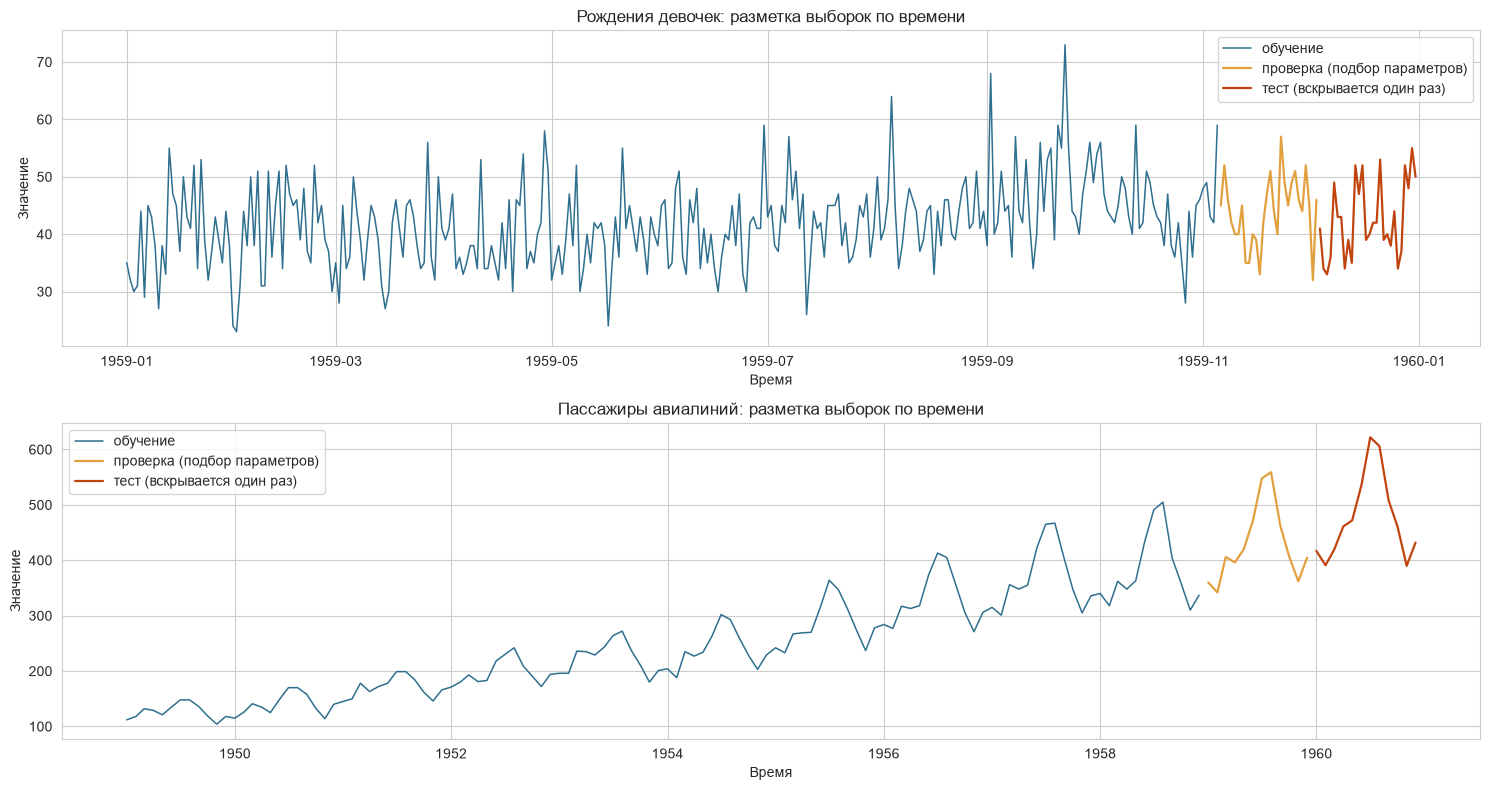

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
for ось, (имя, ряд) in zip(axes, РЯДЫ.items()):
    в = ВЫБОРКИ[имя]
    ось.plot(в['обучение'].index, в['обучение'].values, color='#2f6f8f',
             linewidth=1.1, label='обучение')
    ось.plot(в['проверка'].index, в['проверка'].values, color='#e2a03f',
             linewidth=1.6, label='проверка (подбор параметров)')
    ось.plot(в['тест'].index, в['тест'].values, color='#c1440e',
             linewidth=1.6, label='тест (вскрывается один раз)')
    ось.set_title(f'{имя}: разметка выборок по времени')
    ось.set_xlabel('Время')
    ось.set_ylabel('Значение')
    ось.legend()
plt.tight_layout()
plt.show()

**Вывод по Задаче 2:**

**Разметка получилась несимметричной по доле, и это осознанно.** У рождений на подбор и тест
уходит по 28 дней из 365, то есть обучению остается **309 точек из 365** (85%). У пассажиров
горизонт короче в абсолютном выражении, но ряд короткий, и обучению остается **120 из 144**
(83%). Доли близкие, а вот горизонты меряют разное: у рождений это четыре недели вперед,
у пассажиров - целый год.

**Период сезона подтвердился данными в обоих случаях.** У рождений автокорреляция обучающей части
значима на лагах 1, 2, **7, 8**, 21, 22 и на хвосте 27-30 при пороге 0.114. Лаг 7 выделяется
среди соседей: ACF(6) равен 0.109, **ACF(7) - 0.205**, ACF(9) - 0.107. Тот же недельный ритм
виден напрямую: в среду рождается **43.89** девочки
в день, в воскресенье **38.75**, размах профиля **5.14** при разбросе ряда 7.50. То есть недельная
волна есть, но она меньше собственного шума ряда.

У пассажиров значимы **все 29 лагов подряд**: так выглядит ряд с сильным трендом, где ACF меряет
в первую очередь его, а не сезон. Но и на этом фоне ACF(12) равен **0.743** и стоит локальным
максимумом между 0.631 на лаге 8 и 0.616 на лаге 14 - годовая волна видна прямо в коррелограмме.

Метрика взята **RMSE** как основная и **MAE** рядом с ней. RMSE наказывает крупные промахи
сильнее, чем мелкие, и для прогноза это правильный акцент: ошибиться на 50 пассажиров один раз
хуже, чем на 10 пять раз. MAE стоит рядом, потому что читается в единицах ряда напрямую -
это средний промах в рождениях в день и в тысячах пассажиров в месяц

### Задача 3. Четыре модели и форма прогноза, который они дают

Все четыре модели строятся на одной идее - усреднить прошлое, - но по-разному отвечают
на вопрос, что будет за концом ряда.

*   **MA** усредняет последние `окно` значений. Чтобы получить прогноз дальше чем на один шаг,
    предсказанная точка дописывается в ряд и усредняется уже вместе с остальными.
*   **EMA** держит один уровень и подтягивает его к каждому новому значению с весом `альфа`.
    За концом ряда новых значений нет, поэтому прогноз - горизонтальная прямая на уровне
    последнего сглаженного значения.
*   **DEMA** держит уровень и наклон отдельно: `альфа` отвечает за скорость подстройки уровня,
    `бета` - за скорость подстройки наклона. Прогноз на `m` шагов вперед это уровень плюс `m`
    наклонов, то есть прямая с ненулевым углом.
*   **TEMA** добавляет третью составляющую - сезонный профиль с параметром `гамма`. Прогноз это
    прямая плюс профиль соответствующей позиции внутри сезона.

Начальные значения задаются одинаково для всех: уровень берется первой точкой ряда, наклон -
средним приростом за первый сезон, сезонный профиль - отклонениями каждой позиции сезона
от среднего своего цикла.

Посмотрим на форму прогнозов, пока не подбирая параметры: всем сглаживающим коэффициентам
поставим 0.3, окну MA - двенадцать шагов

In [5]:
def прогноз_ma(x, окно, шагов):
    """скользящее среднее: очередная точка прогноза - среднее последних `окно` значений,
    причем уже предсказанные точки тоже попадают в это среднее"""
    история = list(np.asarray(x, dtype=float))
    прогноз = []
    for _ in range(шагов):
        следующая = float(np.mean(история[-окно:]))
        прогноз.append(следующая)
        история.append(следующая)
    return np.array(прогноз)


def прогноз_ema(x, альфа, шагов):
    """экспоненциальное сглаживание: один уровень, прогноз за концом ряда постоянен"""
    x = np.asarray(x, dtype=float)
    уровень = x[0]
    for y in x[1:]:
        уровень = альфа * y + (1 - альфа) * уровень
    return np.full(шагов, уровень)


def прогноз_dema(x, альфа, бета, шагов):
    """двойное сглаживание: уровень и наклон, прогноз на m шагов это уровень + m наклонов"""
    x = np.asarray(x, dtype=float)
    уровень, наклон = x[0], x[1] - x[0]
    for y in x[1:]:
        прошлый = уровень
        уровень = альфа * y + (1 - альфа) * (уровень + наклон)
        наклон = бета * (уровень - прошлый) + (1 - бета) * наклон
    return уровень + наклон * np.arange(1, шагов + 1)


def старт_сезона(x, сезон):
    """начальный сезонный профиль: отклонение каждой позиции сезона от среднего своего цикла"""
    циклов = len(x) // сезон
    средние = [x[сезон * j: сезон * (j + 1)].mean() for j in range(циклов)]
    return np.array([np.mean([x[сезон * j + i] - средние[j] for j in range(циклов)])
                     for i in range(сезон)])


def старт_наклона(x, сезон):
    """начальный наклон: средний прирост за один шаг, посчитанный через первый сезон"""
    return float(np.mean([(x[i + сезон] - x[i]) / сезон for i in range(сезон)]))


def прогноз_tema(x, альфа, бета, гамма, сезон, шагов):
    """тройное сглаживание: уровень, наклон и сезонный профиль"""
    x = np.asarray(x, dtype=float)
    профиль = старт_сезона(x, сезон).copy()
    уровень, наклон = x[0], старт_наклона(x, сезон)
    for i in range(1, len(x)):
        прошлый = уровень
        уровень = альфа * (x[i] - профиль[i % сезон]) + (1 - альфа) * (уровень + наклон)
        наклон = бета * (уровень - прошлый) + (1 - бета) * наклон
        профиль[i % сезон] = гамма * (x[i] - уровень) + (1 - гамма) * профиль[i % сезон]
    n = len(x)
    return np.array([уровень + m * наклон + профиль[(n + m - 1) % сезон]
                     for m in range(1, шагов + 1)])


def предсказать(модель, история, параметры, сезон, шагов):
    """единая точка входа: любая из четырех моделей строит прогноз на `шагов` вперед.

    нужна затем, что дальше одни и те же вызовы идут в переборе параметров, в замере
    качества и в отрисовке - и различаются только названием модели"""
    if модель == 'MA':
        return прогноз_ma(история, параметры['окно'], шагов)
    if модель == 'EMA':
        return прогноз_ema(история, параметры['альфа'], шагов)
    if модель == 'DEMA':
        return прогноз_dema(история, параметры['альфа'], параметры['бета'], шагов)
    return прогноз_tema(история, параметры['альфа'], параметры['бета'], параметры['гамма'],
                        сезон, шагов)


МОДЕЛИ = ['MA', 'EMA', 'DEMA', 'TEMA']


def качество(факт, прогноз):
    """RMSE и MAE в единицах самого ряда"""
    ошибка = np.asarray(факт, dtype=float) - np.asarray(прогноз, dtype=float)
    return float(np.sqrt(np.mean(ошибка ** 2))), float(np.mean(np.abs(ошибка)))

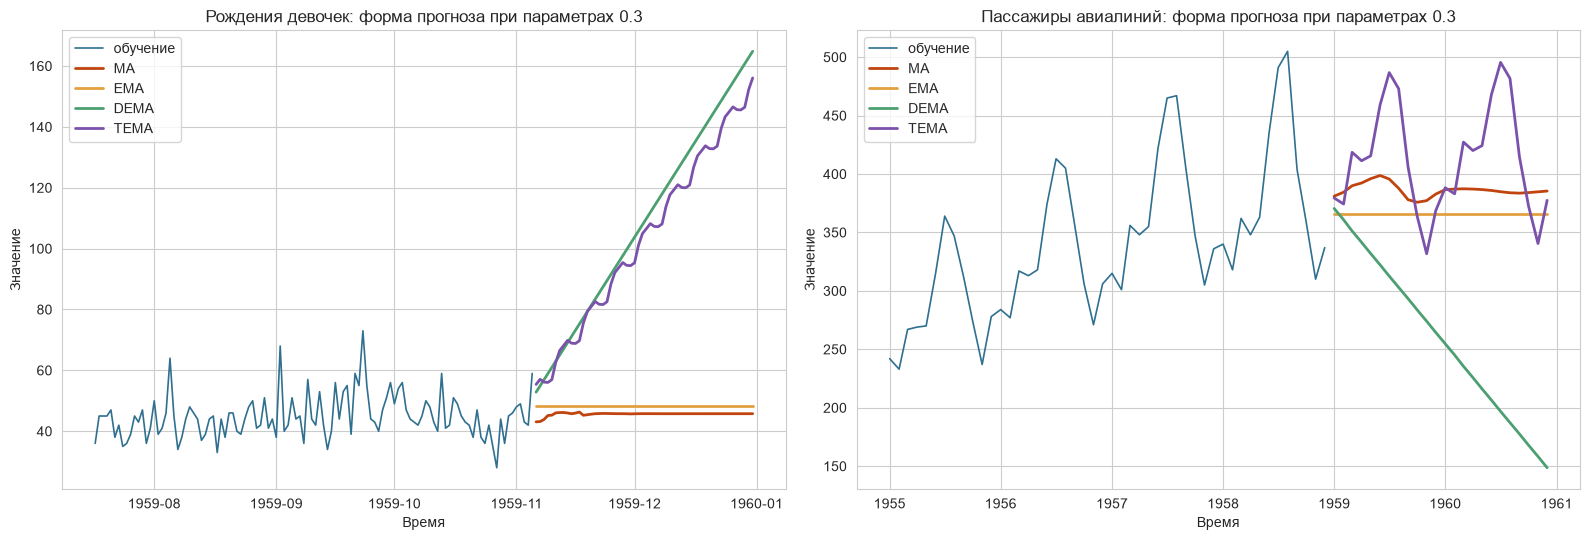

In [6]:
# форма прогноза, параметры еще не подбирались: всем сглаживающим коэффициентам 0.3
демо = {'MA': {'окно': 12}, 'EMA': {'альфа': 0.3},
        'DEMA': {'альфа': 0.3, 'бета': 0.3}, 'TEMA': {'альфа': 0.3, 'бета': 0.3, 'гамма': 0.3}}
цвета = {'MA': '#c1440e', 'EMA': '#e2a03f', 'DEMA': '#4c9f70', 'TEMA': '#7b52ab'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for ось, имя in zip(axes, РЯДЫ):
    в = ВЫБОРКИ[имя]
    история, h = в['обучение'], ГОРИЗОНТ[имя] * 2
    будущее = РЯДЫ[имя].index[len(история):len(история) + h]
    хвост = история[-h * 2:]
    ось.plot(хвост.index, хвост.values, color='#2f6f8f', linewidth=1.2, label='обучение')
    for модель in МОДЕЛИ:
        ось.plot(будущее, предсказать(модель, история, демо[модель], СЕЗОН[имя], h),
                 color=цвета[модель], linewidth=2, label=модель)
    ось.set_title(f'{имя}: форма прогноза при параметрах 0.3')
    ось.set_xlabel('Время')
    ось.set_ylabel('Значение')
    ось.legend()
plt.tight_layout()
plt.show()

**Вывод по Задаче 3:**

**Четыре модели дают четыре разные формы прогноза, и видно это до всякого подбора параметров.**

*   **EMA рисует строго горизонтальную прямую.** Иначе и быть не может: за концом ряда новых
    значений нет, а уровень меняется только от них.
*   **MA выходит на горизонталь не сразу, и по дороге успевает кое-что показать.** Первые `окно`
    шагов в среднее еще попадают настоящие точки ряда, и прогноз повторяет их форму в ослабленном
    виде. У пассажиров при окне в двенадцать месяцев на графике видно ослабленное эхо прошлогодней
    волны: подъем к середине первого года и спад к его концу. Дальше настоящие точки из окна
    вымываются, и линия замирает.
*   **DEMA уходит по прямой под углом.** Наклон она берет из последних наблюдений и продолжает
    его сколько угодно далеко. На рождениях при бете 0.3 она улетает вверх, у пассажиров -
    вниз, хотя ряд двенадцать лет растет: обучение кончается в декабре, сразу после осеннего
    спада с летнего пика, и этот спад модель приняла за наклон ряда.
*   **TEMA повторяет тот же наклон, но с волной.** У пассажиров эта волна воспроизводит годовой
    ход с летним пиком, у рождений она мелкая - недельный профиль на фоне куда большего шума.

**Отсюда сразу понятно, за счет чего модели будут различаться.** Разница между ними не в том,
как они сглаживают прошлое - там они похожи, - а в том, что каждая считает продолжением ряда:
постоянный уровень, уровень с наклоном или уровень с наклоном и волной. Что из этого окажется
ближе к правде, зависит от ряда, и ровно это дальше и меряется

### Задача 4. Подбор параметров на стационарном ряде

Параметры перебираются полностью по сетке, а не оптимизатором. Причина простая: параметров
у самой богатой модели три, сетка укладывается в секунды, а результат перебора воспроизводится
при повторном запуске в точности. У оптимизатора же ответ зависит от начальной точки, и на
негладкой поверхности он останавливается там, куда его завел первый шаг.

Сетки взяты разной частоты. У MA параметр целый - перебираются все окна от одного шага
до трети обучающей выборки. У EMA параметр один, поэтому сетка мелкая, с шагом 0.01.
У DEMA и TEMA параметров два и три, и шаг взят 0.05.

Критерий один для всех - RMSE прогноза на проверочном отрезке. Прогноз строится на все 28 дней
сразу, а не на один день вперед: параметры должны подбираться под тот горизонт, на котором
их спросят

In [7]:
СЕТКА_АЛЬФА = np.round(np.arange(0.01, 1.0, 0.01), 2)      # у EMA параметр один, сетка мелкая
СЕТКА_ГЛАДКАЯ = np.round(np.arange(0.05, 1.0, 0.05), 2)    # у DEMA и TEMA параметров два и три


def варианты(модель, длина_обучения):
    """все наборы параметров модели, которые перебираются на проверочном отрезке"""
    if модель == 'MA':
        return [{'окно': n} for n in range(1, длина_обучения // 3 + 1)]
    if модель == 'EMA':
        return [{'альфа': float(a)} for a in СЕТКА_АЛЬФА]
    if модель == 'DEMA':
        return [{'альфа': float(a), 'бета': float(b)}
                for a in СЕТКА_ГЛАДКАЯ for b in СЕТКА_ГЛАДКАЯ]
    return [{'альфа': float(a), 'бета': float(b), 'гамма': float(g)}
            for a in СЕТКА_ГЛАДКАЯ for b in СЕТКА_ГЛАДКАЯ for g in СЕТКА_ГЛАДКАЯ]


def подобрать(имя):
    """полный перебор сетки: для каждой модели список (RMSE на проверке, параметры),
    отсортированный от лучшего набора к худшему"""
    в, h = ВЫБОРКИ[имя], ГОРИЗОНТ[имя]
    итог = {}
    for модель in МОДЕЛИ:
        оценки = [(качество(в['проверка'],
                            предсказать(модель, в['обучение'], п, СЕЗОН[имя], h))[0], п)
                  for п in варианты(модель, len(в['обучение']))]
        итог[модель] = sorted(оценки, key=lambda з: з[0])
    return итог


def подпись(параметры):
    return ' '.join(f'{к}={з}' for к, з in параметры.items())


def показать_подбор(имя, подбор):
    """две таблицы: лучший набор каждой модели и пятерка лучших, чтобы видеть,
    насколько оптимум плоский"""
    лучшие = [{'модель': м, 'параметры': подпись(подбор[м][0][1]),
               'RMSE на проверке': round(подбор[м][0][0], 3),
               'наборов перебрано': len(подбор[м])} for м in МОДЕЛИ]
    print(f'{имя}: лучший набор параметров каждой модели')
    print(pd.DataFrame(лучшие).to_string(index=False))

    пятерки = [{'модель': м, 'место': место, 'параметры': подпись(п), 'RMSE': round(r, 3)}
               for м in МОДЕЛИ for место, (r, п) in enumerate(подбор[м][:5], 1)]
    print('\nпять лучших наборов у каждой модели:')
    print(pd.DataFrame(пятерки).to_string(index=False))


ПОДБОР = {'Рождения девочек': подобрать('Рождения девочек')}
показать_подбор('Рождения девочек', ПОДБОР['Рождения девочек'])

Рождения девочек: лучший набор параметров каждой модели
модель                     параметры  RMSE на проверке  наборов перебрано
    MA                       окно=25             5.667                103
   EMA                    альфа=0.08             5.983                 99
  DEMA          альфа=0.15 бета=0.05             5.959                361
  TEMA альфа=0.05 бета=0.2 гамма=0.4             5.801               6859

пять лучших наборов у каждой модели:
модель  место                       параметры  RMSE
    MA      1                         окно=25 5.667
    MA      2                         окно=26 5.678
    MA      3                         окно=23 5.695
    MA      4                         окно=24 5.696
    MA      5                         окно=22 5.699
   EMA      1                      альфа=0.08 5.983
   EMA      2                      альфа=0.07 5.986
   EMA      3                      альфа=0.09 5.986
   EMA      4                       альфа=0.1 5.993
   EMA      5   

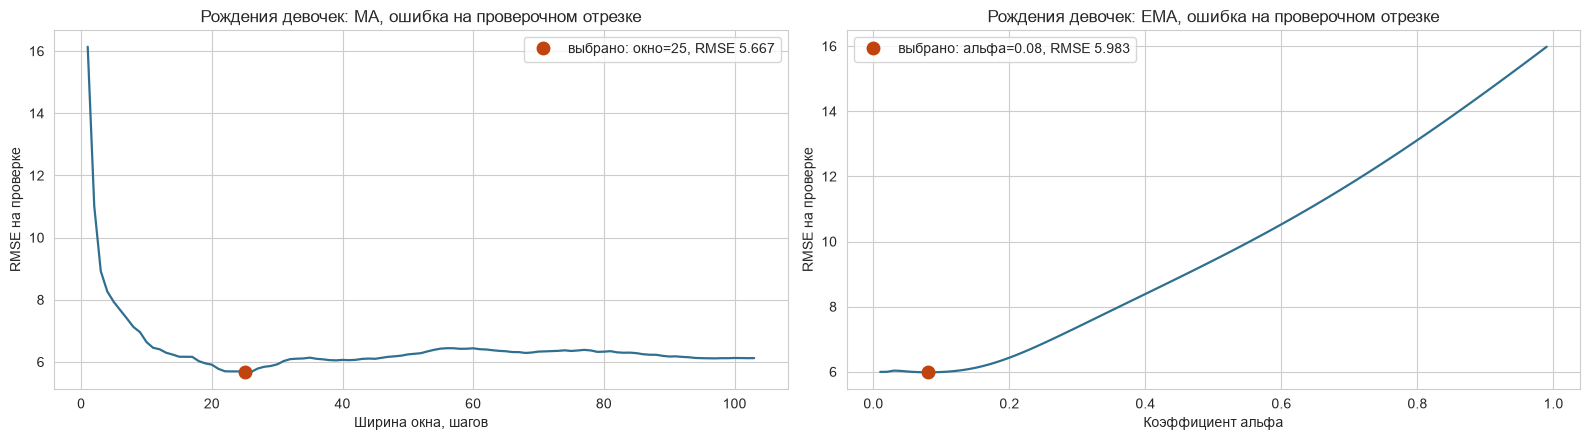

Рождения девочек: RMSE у MA при разных окнах - окно 1 - 16.140, окно 2 - 11.012, окно 3 - 8.922, окно 7 - 7.398, окно 14 - 6.238, окно 21 - 5.778, окно 25 - 5.667, окно 28 - 5.844, окно 40 - 6.066, окно 60 - 6.439, окно 90 - 6.174


In [8]:
def кривые_подбора(имя, подбор):
    """как ошибка на проверке зависит от параметра там, где параметр один: окно MA и альфа EMA"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
    for ось, модель, ключ, подпись_оси in [(axes[0], 'MA', 'окно', 'Ширина окна, шагов'),
                                           (axes[1], 'EMA', 'альфа', 'Коэффициент альфа')]:
        x = [п[ключ] for _, п in sorted(подбор[модель], key=lambda з: з[1][ключ])]
        y = [r for r, _ in sorted(подбор[модель], key=lambda з: з[1][ключ])]
        ось.plot(x, y, color='#2f6f8f', linewidth=1.6)
        r, п = подбор[модель][0]
        ось.plot(п[ключ], r, 'o', color='#c1440e', markersize=9,
                 label=f'выбрано: {ключ}={п[ключ]}, RMSE {r:.3f}')
        ось.set_title(f'{имя}: {модель}, ошибка на проверочном отрезке')
        ось.set_xlabel(подпись_оси)
        ось.set_ylabel('RMSE на проверке')
        ось.legend()
    plt.tight_layout()
    plt.show()

    # опорные точки кривой MA: по графику форма видна, а числа нужны для вывода
    по_окну = {п['окно']: r for r, п in подбор['MA']}
    опорные = [n for n in [1, 2, 3, 7, 14, 21, 25, 28, 40, 60, 90] if n in по_окну]
    print(f'{имя}: RMSE у MA при разных окнах - '
          + ', '.join(f'окно {n} - {по_окну[n]:.3f}' for n in опорные))


кривые_подбора('Рождения девочек', ПОДБОР['Рождения девочек'])

**Вывод по Задаче 4:**

**На этом ряде перебор не столько выбирает победителя, сколько показывает, куда каждая модель
сваливается.** Все четыре укладываются в узкую полосу **5.667-5.983** по RMSE: разница между
лучшей и худшей моделью 5%, при том что собственный разброс обучающей части 7.50. Различить модели
такой разницей нельзя.

**Зато сам выбранный набор параметров говорит много.** Перебор в каждой модели выкрутил параметры
в сторону постоянного уровня.

*   **MA взяла окно 25 дней** - почти месяц. Соседние окна с 22 по 26 дают 5.667-5.699, то есть
    оптимум плоский по дну, но не по краям: кривая круто падает от **16.140** при окне в один день
    до **6.238** при окне в две недели, дальше идет пологое дно в районе 20-30 дней
    и медленный подъем обратно к **6.439** при окне в два месяца.
*   **EMA взяла альфу 0.08** - самое медленное сглаживание из разумных. Значения от 0.06 до 0.10
    дают 5.983-5.994. Малая альфа означает, что новое наблюдение почти не двигает уровень,
    а это то же самое, что усреднить длинный кусок прошлого.
*   **DEMA взяла бету 0.05**, то есть наименьшую из сетки. Бета отвечает за подстройку наклона,
    и перебор фактически попросил модель наклон не менять.
*   **TEMA взяла альфу 0.05 и гамму 0.4**, набрав 5.801 - формально второе место.

**Три модели из четырех сами свелись к усреднению уровня**, и это ровно то, чего ждешь от ряда
без тренда. Стоит ли доверять их порядку между собой, покажет тест: сейчас разница между ними
меньше, чем шаг сетки мог бы объяснить

### Задача 5. Подбор параметров на нестационарном ряде

Тот же перебор, тот же критерий, только горизонт теперь 12 месяцев, а период сезона 12.
Ряд здесь устроен иначе - растет и колеблется, - и интересно, попросит ли перебор у моделей
чего-то другого, чем на рождениях

Пассажиры авиалиний: лучший набор параметров каждой модели
модель                    параметры  RMSE на проверке  наборов перебрано
    MA                      окно=13            74.818                 40
   EMA                   альфа=0.15            84.509                 99
  DEMA          альфа=0.05 бета=0.1            65.122                361
  TEMA альфа=0.2 бета=0.4 гамма=0.7             8.214               6859

пять лучших наборов у каждой модели:
модель  место                      параметры   RMSE
    MA      1                        окно=13 74.818
    MA      2                        окно=14 75.346
    MA      3                        окно=12 76.325
    MA      4                        окно=15 77.202
    MA      5                        окно=16 79.242
   EMA      1                     альфа=0.15 84.509
   EMA      2                     альфа=0.14 84.563
   EMA      3                     альфа=0.16 84.565
   EMA      4                     альфа=0.17 84.714
   EMA      5     

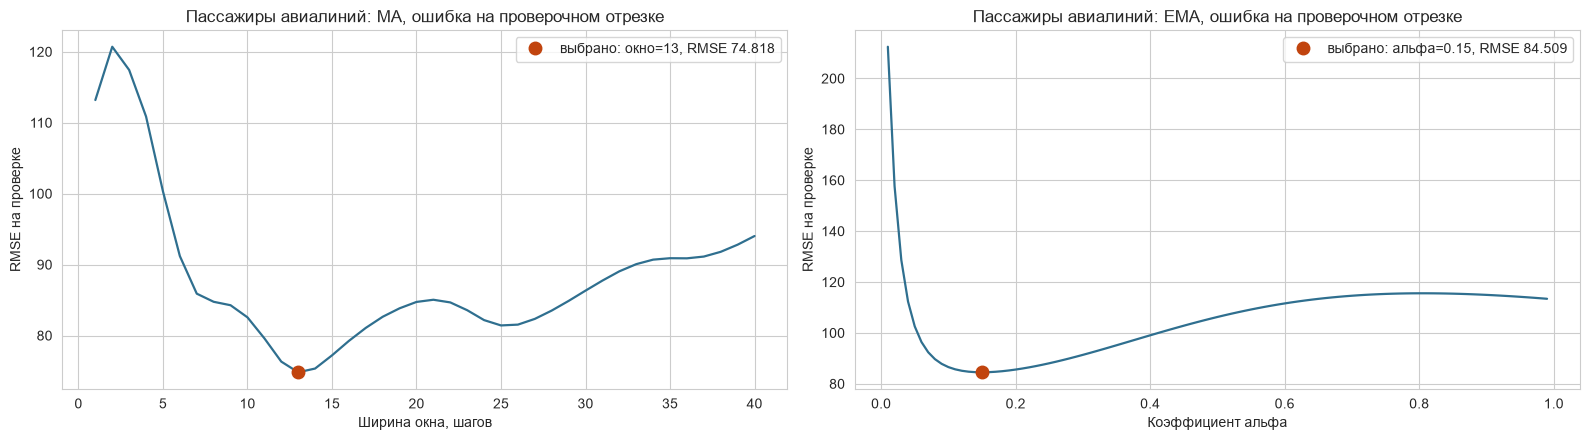

Пассажиры авиалиний: RMSE у MA при разных окнах - окно 1 - 113.189, окно 2 - 120.699, окно 3 - 117.427, окно 7 - 85.900, окно 14 - 75.346, окно 21 - 85.043, окно 25 - 81.423, окно 28 - 83.518, окно 40 - 94.023

прогноз на проверочный год при лучших параметрах:
  месяц  факт    MA   EMA  DEMA  TEMA
1959-01   360 377.5 376.6 418.3 358.7
1959-02   342 380.7 376.6 421.0 348.2
1959-03   406 383.9 376.6 423.6 402.9
1959-04   396 388.9 376.6 426.3 401.0
1959-05   420 391.0 376.6 428.9 421.4
1959-06   472 394.3 376.6 431.6 494.4
1959-07   548 396.7 376.6 434.3 545.7
1959-08   559 393.8 376.6 436.9 548.9
1959-09   463 386.3 376.6 439.6 459.4
1959-10   407 377.2 376.6 442.2 410.0
1959-11   362 375.1 376.6 444.9 364.2
1959-12   405 376.3 376.6 447.5 395.3

среднее за год: факт 428.3, MA 385.1, EMA 376.6, DEMA 432.9, TEMA 429.2


In [9]:
ПОДБОР['Пассажиры авиалиний'] = подобрать('Пассажиры авиалиний')
показать_подбор('Пассажиры авиалиний', ПОДБОР['Пассажиры авиалиний'])
кривые_подбора('Пассажиры авиалиний', ПОДБОР['Пассажиры авиалиний'])

# что каждая модель предсказала на проверочном году при своих лучших параметрах
в = ВЫБОРКИ['Пассажиры авиалиний']
сводка = pd.DataFrame({'месяц': в['проверка'].index.strftime('%Y-%m'),
                       'факт': в['проверка'].values.astype(int)})
for модель in МОДЕЛИ:
    сводка[модель] = np.round(предсказать(модель, в['обучение'], ПОДБОР['Пассажиры авиалиний'][модель][0][1],
                                          СЕЗОН['Пассажиры авиалиний'], ГОРИЗОНТ['Пассажиры авиалиний']), 1)
print('\nпрогноз на проверочный год при лучших параметрах:')
print(сводка.to_string(index=False))
print('\nсреднее за год: факт %.1f, ' % в['проверка'].mean()
      + ', '.join(f'{м} {сводка[м].mean():.1f}' for м in МОДЕЛИ))

**Вывод по Задаче 5:**

**Здесь модели разошлись не на проценты, а в разы.** TEMA дает на проверке **8.214**, следующая
за ней DEMA - **65.122**, то есть в восемь раз хуже. MA **74.818**, EMA **84.509**. Никакой
неразличимости, как на рождениях, тут нет.

**Три модели без сезона уперлись в одно и то же препятствие - годовую волну.** Ее они описать
не умеют ничем, и лучшее, что им остается, - идти посередине между летним пиком и зимним
провалом. Прямое подтверждение видно в выбранном окне MA: перебор остановился на **13 месяцах**,
соседние 12 и 14 дают почти то же (76.3 и 75.3). Окно длиной в год - это в точности способ
сгладить годовую волну целиком, и перебор пришел к нему сам.

**EMA оказалась хуже MA, и таблица прогнозов объясняет, чем именно.** Обе модели занижают
уровень: среднее по проверочному году у MA **385.1**, у EMA **376.6** при фактических **428.3**.
Но MA внутри года не стоит на месте - она поднимается до 396.7 к июлю и опускается до 375.1
к ноябрю, повторяя в ослабленном виде волну 1958 года, которая еще не вышла из ее окна.
EMA все двенадцать месяцев держит одно значение 376.6. Годовая волна в факте идет от 342
до 559, и эхо, пусть слабое, оказывается лучше прямой.

**DEMA впервые оказалась полезной:** 65.1 против 74.8 у MA. На рождениях наклон был лишней
деталью, здесь он часть устройства ряда. Но выбранные параметры осторожные - альфа 0.05,
бета 0.1, - то есть модель просит брать наклон по длинной истории, а не по последним месяцам.

**TEMA взяла гамму 0.7** - высокую. Сезонный профиль ей нужно обновлять быстро, и это понятно:
летний пик растет вместе с потоком, профиль, посчитанный по началу ряда, к 1959 году уже мал

### Задача 6. Прогноз на отложенный последний период

Параметры зафиксированы. Теперь каждая модель заново проходит **всю** историю до теста, то есть
обучение вместе с проверкой, и строит прогноз на последний период ряда: 28 дней у рождений,
12 месяцев у пассажиров. Тест до этого момента не участвовал ни в чем.

Рядом с моделями считаются две точки отсчета. Они не участвуют в сравнении как пятая и шестая
модель, их роль другая - показать, с чем вообще сравнивается результат.

*   **Наивный прогноз** повторяет последнее известное значение на весь горизонт. Модель, которая
    его не обходит, не сделала ничего.
*   **Сезонный наивный** повторяет последний полный сезон. Он показывает, сколько ошибки
    объясняется одной только сезонной волной, без всякого сглаживания

In [10]:
ПРОГНОЗ, ИТОГ = {}, []
for имя in РЯДЫ:
    в, h, с = ВЫБОРКИ[имя], ГОРИЗОНТ[имя], СЕЗОН[имя]
    история = в['до теста']                      # обучение вместе с проверкой
    ПРОГНОЗ[имя] = {м: предсказать(м, история, ПОДБОР[имя][м][0][1], с, h) for м in МОДЕЛИ}
    # точки отсчета: постоянное последнее значение и повторенный последний сезон
    ПРОГНОЗ[имя]['наивный'] = np.full(h, float(история.iloc[-1]))
    ПРОГНОЗ[имя]['сезонный наивный'] = np.asarray(история.values[-с:], dtype=float)[
        [i % с for i in range(h)]]

    for м, з in ПРОГНОЗ[имя].items():
        rmse, mae = качество(в['тест'], з)
        ИТОГ.append({'ряд': имя, 'модель': м, 'параметры':
                     подпись(ПОДБОР[имя][м][0][1]) if м in МОДЕЛИ else '-',
                     'RMSE на проверке': round(ПОДБОР[имя][м][0][0], 3) if м in МОДЕЛИ else np.nan,
                     'RMSE на тесте': round(rmse, 3), 'MAE на тесте': round(mae, 3),
                     'MAE к разбросу ряда': round(mae / float(история.std()), 3)})

ИТОГ = pd.DataFrame(ИТОГ)
print(ИТОГ.to_string(index=False))

                ряд           модель                     параметры  RMSE на проверке  RMSE на тесте  MAE на тесте  MAE к разбросу ряда
   Рождения девочек               MA                       окно=25             5.667          6.725         5.999                0.810
   Рождения девочек              EMA                    альфа=0.08             5.983          6.871         6.124                0.827
   Рождения девочек             DEMA          альфа=0.15 бета=0.05             5.959          7.211         6.438                0.869
   Рождения девочек             TEMA альфа=0.05 бета=0.2 гамма=0.4             5.801          9.355         7.934                1.071
   Рождения девочек          наивный                             -               NaN          7.399         6.607                0.892
   Рождения девочек сезонный наивный                             -               NaN          9.894         8.036                1.084
Пассажиры авиалиний               MA                   

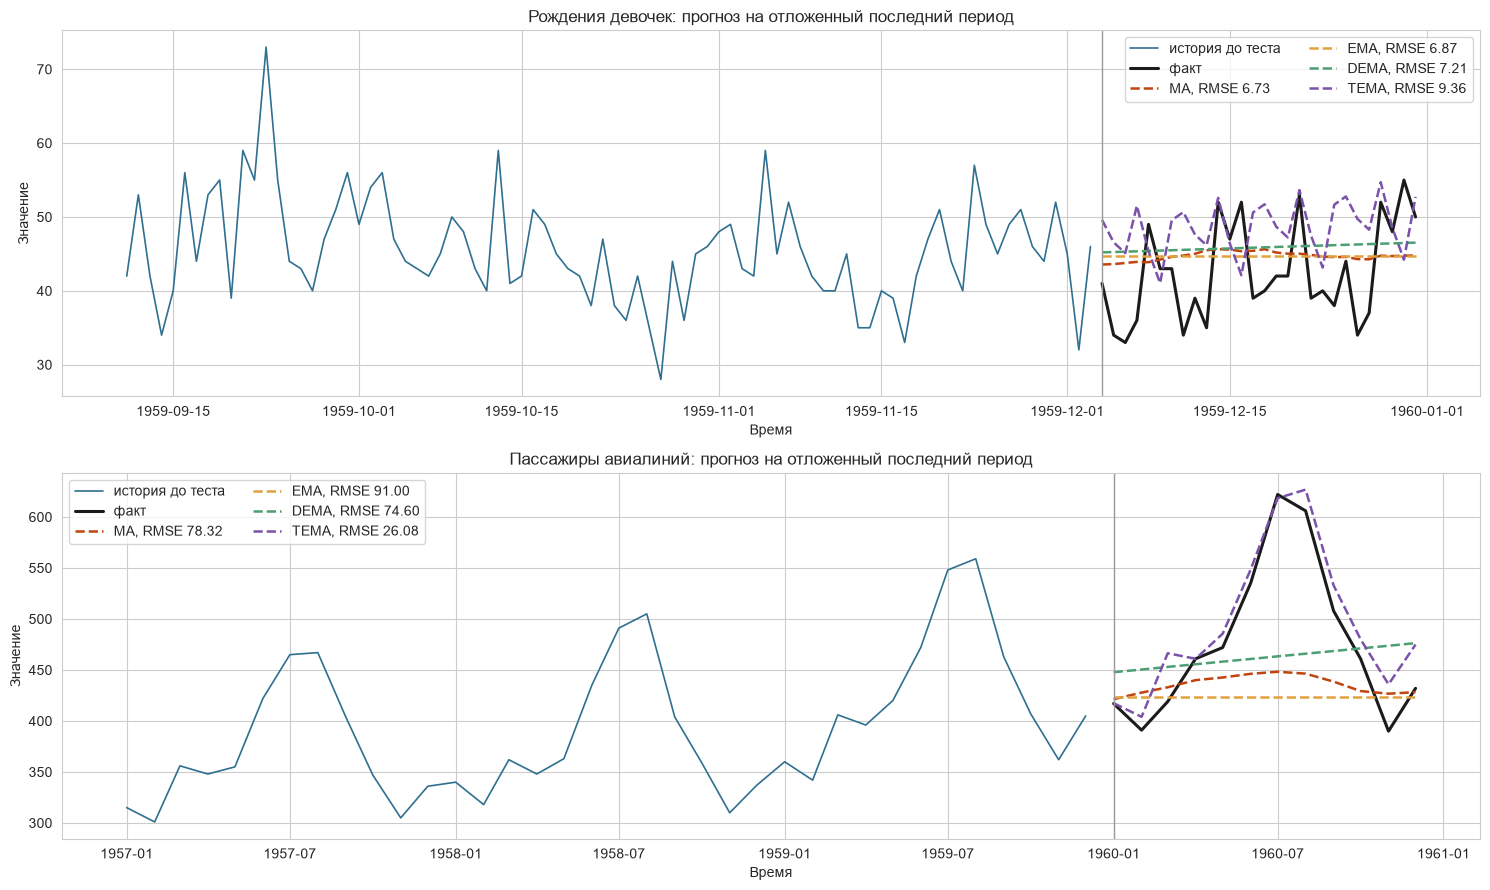

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9))
for ось, имя in zip(axes, РЯДЫ):
    в, h = ВЫБОРКИ[имя], ГОРИЗОНТ[имя]
    хвост = в['до теста'][-3 * h:]
    ось.plot(хвост.index, хвост.values, color='#2f6f8f', linewidth=1.2, label='история до теста')
    ось.plot(в['тест'].index, в['тест'].values, color='#1b1b1b', linewidth=2.2, label='факт')
    for модель in МОДЕЛИ:
        ось.plot(в['тест'].index, ПРОГНОЗ[имя][модель], color=цвета[модель],
                 linewidth=1.8, linestyle='--',
                 label=f'{модель}, RMSE {качество(в["тест"], ПРОГНОЗ[имя][модель])[0]:.2f}')
    ось.axvline(в['тест'].index[0], color='#999999', linewidth=1)
    ось.set_title(f'{имя}: прогноз на отложенный последний период')
    ось.set_xlabel('Время')
    ось.set_ylabel('Значение')
    ось.legend(ncol=2)
plt.tight_layout()
plt.show()

**Вывод по Задаче 6:**

**На тесте порядок моделей сохранился только у пассажиров.** Там TEMA дает **26.080** против
74.599 у DEMA, 78.321 у MA и 91.000 у EMA - тот же порядок, что и на проверке. На рождениях
порядок перевернулся: TEMA была второй на проверке (5.801) и стала последней на тесте (**9.355**),
хуже даже наивного прогноза.

**Ошибка везде выросла при переходе с проверки на тест, и выросла неодинаково.** У рождений MA
прибавила 19% (5.667 -> 6.725), а TEMA 61% (5.801 -> 9.355). У пассажиров TEMA прибавила втрое
(8.214 -> 26.080). Чем больше у модели параметров, тем сильнее ее результат на проверочном
отрезке оказался удачей: у TEMA три параметра подбирались по 28 и по 12 точкам соответственно,
и такой подбор попадает не только в устройство ряда, но и в его случайную часть.

**Обе точки отсчета оказались на своем месте.** У рождений наивный прогноз дает 7.399, и три
модели из четырех его обходят, а сезонный наивный - 9.894, худший результат в таблице: повторять
прошлую неделю на ряде, где недельная волна меньше шума, значит переносить в прогноз чужой шум.
У пассажиров наоборот: сезонный наивный **50.708** вдвое лучше обычного наивного **102.977**.
Половина всей ошибки простых моделей на этом ряде - это ненарисованная годовая волна.

**Столбец «MAE к разбросу ряда» позволяет сравнить два ряда между собой**, чего абсолютные числа
не позволяют. У пассажиров лучший результат **0.192**, то есть прогноз объясняет большую часть
изменчивости. У рождений лучший **0.810** - модель едва обходит простое усреднение. Растущий
ряд с четкой сезонностью предсказывать легче, чем шум вокруг постоянного уровня

### Задача 7. Оптимальная модель для каждого ряда

Числа в таблице - средние по 28 и 12 точкам, и на таких длинах разница в несколько процентов
может быть просто удачным расположением точек. Поэтому выбор проверяется не только средним:
у каждой модели есть **вектор** ошибок по тестовым точкам, и две модели сравниваются на одних
и тех же точках парно, критерием Уилкоксона по абсолютным ошибкам.

Сравниваются только те пары, на которых держится вывод: лидер против каждого из соперников

In [12]:
from scipy import stats

пары = {'Рождения девочек': [('MA', 'EMA'), ('MA', 'DEMA'), ('MA', 'TEMA'), ('MA', 'наивный')],
        'Пассажиры авиалиний': [('TEMA', 'DEMA'), ('TEMA', 'MA'), ('TEMA', 'EMA'),
                                ('TEMA', 'сезонный наивный')]}

сравнение = []
for имя, список in пары.items():
    факт = np.asarray(ВЫБОРКИ[имя]['тест'].values, dtype=float)
    for лидер, соперник in список:
        ошибка_л = np.abs(факт - ПРОГНОЗ[имя][лидер])
        ошибка_с = np.abs(факт - ПРОГНОЗ[имя][соперник])
        сравнение.append({'ряд': имя, 'лидер': лидер, 'соперник': соперник,
                          'MAE лидера': round(float(ошибка_л.mean()), 3),
                          'MAE соперника': round(float(ошибка_с.mean()), 3),
                          'точек, где лидер точнее': f'{int((ошибка_л < ошибка_с).sum())} из {len(факт)}',
                          'p-value Уилкоксона': round(stats.wilcoxon(ошибка_л, ошибка_с).pvalue, 4)})

print(pd.DataFrame(сравнение).to_string(index=False))

print('\nитог по каждому ряду:')
for имя in РЯДЫ:
    строки = ИТОГ[(ИТОГ['ряд'] == имя) & (ИТОГ['модель'].isin(МОДЕЛИ))]
    лучшая = строки.loc[строки['RMSE на тесте'].idxmin()]
    print(f'  {имя}: {лучшая["модель"]} ({лучшая["параметры"]}), '
          f'RMSE {лучшая["RMSE на тесте"]}, MAE {лучшая["MAE на тесте"]}')

                ряд лидер         соперник  MAE лидера  MAE соперника точек, где лидер точнее  p-value Уилкоксона
   Рождения девочек    MA              EMA       5.999          6.124                19 из 28              0.2183
   Рождения девочек    MA             DEMA       5.999          6.438                19 из 28              0.1200
   Рождения девочек    MA             TEMA       5.999          7.934                20 из 28              0.0204
   Рождения девочек    MA          наивный       5.999          6.607                19 из 28              0.0179
Пассажиры авиалиний  TEMA             DEMA      20.436         57.833                10 из 12              0.0161
Пассажиры авиалиний  TEMA               MA      20.436         55.768                 9 из 12              0.0923
Пассажиры авиалиний  TEMA              EMA      20.436         65.397                 9 из 12              0.0771
Пассажиры авиалиний  TEMA сезонный наивный      20.436         47.833                 9 

**Вывод по Задаче 7:**

*   **Рождения девочек - MA с окном 25 дней.** RMSE **6.725**, MAE **5.999**, то есть средний
    промах шесть рождений в день при среднем уровне 42.5. Формально это лучший результат,
    но парное сравнение уточняет, насколько он лучший: против EMA **p-value 0.2183**,
    против DEMA **0.1200**. От этих двух моделей MA не отличима - на 28 точках такую разницу
    не поймать. А вот против наивного прогноза (**0.0179**) и против TEMA (**0.0204**) разница
    устойчива. Значит правильный ответ по этому ряду не «именно MA», а **любая модель без
    тренда и без сезона**; MA просто оказалась в этой группе первой по числу.
*   **Пассажиры авиалиний - TEMA с альфа 0.2, бета 0.4, гамма 0.7.** RMSE **26.080** против
    74.599 у ближайшего соперника, MAE **20.436** при среднем уровне 476. Против DEMA
    **p-value 0.0161**, против сезонного наивного **0.0122** - разница устойчива. Против MA
    получилось **0.0923**, и это не про модели, а про длину теста: двенадцати точек критерию
    не хватает, чтобы объявить значимой даже трехкратную разницу в MAE (20.4 против 55.8).

**Общий вывод из двух рядов один: выигрывает не более сложная модель, а та, устройство которой
совпало с устройством ряда.** TEMA на пассажирах лучше MA втрое (26.080 против 78.321),
а на рождениях хуже MA почти в полтора раза (9.355 против 6.725) - и это одна и та же модель
с одинаково честно подобранными параметрами.

*   **Тренд и сезон стоят денег, даже когда их нет.** Каждая лишняя составляющая - это параметр,
    который подбирается по конечной выборке и потому подбирается неточно. На ряде без тренда
    DEMA тратит наклон на случайный сдвиг последних недель, на ряде без выраженной волны TEMA
    вписывает в прогноз недельный профиль, который меньше собственного шума ряда (размах 5.14
    при разбросе 7.50).
*   **Обратное тоже верно и стоит дороже.** На пассажирах отказ от сезонной составляющей
    не «немного ухудшает» прогноз, а обрушивает его: любая модель без сезона проигрывает даже
    механическому повторению прошлого года (50.708 против 74.599 у лучшей из них).
*   **Признак, по которому это можно решить заранее, виден до всякого прогноза.** У пассажиров
    ACF(12) на обучающей части 0.743 и годовая волна размахом в сотни тысяч пассажиров;
    у рождений ACF(7) равен 0.205 при пороге значимости 0.114 - волна есть, но она тонет
    в шуме. Сезонную составляющую имеет смысл заводить там, где сезонный сигнал больше шума,
    а не там, где он просто отличим от нуля

### Дополнительный эксперимент 1 (вне рамок задания). Как быстро стареет прогноз

В основной части все модели сравнивались одним числом на весь горизонт. Но горизонт неоднороден:
на первом шаге модели опираются на настоящие последние наблюдения, а к концу горизонта уже целиком
на собственную конструкцию. Разобьем ошибку по участкам горизонта и посмотрим, где именно модели
расходятся

In [13]:
старение = []
for имя in РЯДЫ:
    h = ГОРИЗОНТ[имя]
    факт = np.asarray(ВЫБОРКИ[имя]['тест'].values, dtype=float)
    четверть = h // 4
    участки = [(1, 1), (1, четверть), (четверть + 1, h // 2), (h // 2 + 1, h)]
    for модель in МОДЕЛИ:
        з = ПРОГНОЗ[имя][модель]
        строка = {'ряд': имя, 'модель': модель}
        for a, b in участки:
            строка[f'шаги {a}-{b}'] = round(качество(факт[a - 1:b], з[a - 1:b])[0], 2)
        старение.append(строка)

for имя in РЯДЫ:
    print(pd.DataFrame([с for с in старение if с['ряд'] == имя]).dropna(axis=1).to_string(index=False))
    print()

             ряд модель  шаги 1-1  шаги 1-7  шаги 8-14  шаги 15-28
Рождения девочек     MA      2.56      6.63       7.47        6.37
Рождения девочек    EMA      3.65      7.19       7.41        6.42
Рождения девочек   DEMA      4.20      7.64       7.72        6.71
Рождения девочек   TEMA      8.60      9.85      10.07        8.71

                ряд модель  шаги 1-1  шаги 1-3  шаги 4-6  шаги 7-12
Пассажиры авиалиний     MA      4.31     22.87     55.34     102.35
Пассажиры авиалиний    EMA      6.81     19.54     73.19     117.02
Пассажиры авиалиний   DEMA     30.82     43.34     43.71      96.10
Пассажиры авиалиний   TEMA      0.48     28.36     11.01      29.96



**Вывод по дополнительному эксперименту 1:**

**У пассажиров на первом шаге все четыре модели работают, а к концу года остается одна.** RMSE
первого шага: TEMA **0.48**, MA **4.31**, EMA **6.81**, DEMA **30.82**. К шагам 7-12 картина
другая: TEMA **29.96**, DEMA **96.10**, MA **102.35**, EMA **117.02**. То есть простые модели
проигрывают не потому, что плохо описывают текущий уровень, а потому, что не умеют его
продолжать.

**Разрыв нарастает не равномерно.** На шагах 1-3 MA (**22.87**) оказывается даже точнее TEMA
(**28.36**): в январе-марте 1960 года поток шел ровно, а TEMA в этот момент уже тянула вверх
свой годовой профиль. Преимущество TEMA целиком набирается на летнем пике - шаги 4-6 дают
**11.01** против 55.34 у MA.

**У рождений старения нет вовсе.** Ошибка каждой модели держится на одном уровне от начала
горизонта к концу: у MA 6.63 на первой неделе и 6.37 на шагах 15-28. Причина в том, что прогноз
у всех почти горизонтален, а ряд колеблется вокруг постоянного уровня - удаление от последнего
наблюдения ничего не меняет. Единственное исключение - первый шаг (**2.56** у MA): он один
попадает в еще не забытую инерцию ряда

### Дополнительный эксперимент 2 (вне рамок задания). Логарифм перед TEMA

У пассажиров размах годовой волны растет вместе с уровнем потока: летний пик 1960 года выше
не на столько же тысяч, на сколько был выше пик 1950-го, а во столько же раз. TEMA в том виде,
как она реализована здесь, складывает уровень с сезонным профилем, то есть считает сезонность
добавкой в тысячах пассажиров, а не долей.

Обычный способ обойти это - взять логарифм: в логарифме постоянная доля превращается
в постоянную добавку. Подберем параметры и посчитаем ошибку заново, вернув прогноз в исходные
единицы через экспоненту. Ошибка меряется в пассажирах, иначе ее не с чем сравнивать

In [14]:
имя = 'Пассажиры авиалиний'
в, h, с = ВЫБОРКИ[имя], ГОРИЗОНТ[имя], СЕЗОН[имя]
лог = {к: np.log(v) for к, v in в.items()}

# параметры подбираются в логарифме, но RMSE считается в пассажирах: сравнивать надо сравнимое
оценки = sorted(((качество(в['проверка'],
                           np.exp(предсказать('TEMA', лог['обучение'], п, с, h)))[0], п)
                 for п in варианты('TEMA', len(в['обучение']))), key=lambda з: з[0])
лучший = оценки[0][1]
print(f'лучший набор в логарифме: {подпись(лучший)}, RMSE на проверке {оценки[0][0]:.3f}')

прогноз_лог = np.exp(предсказать('TEMA', лог['до теста'], лучший, с, h))
факт = np.asarray(в['тест'].values, dtype=float)
сравнение_лог = pd.DataFrame([
    {'вариант': 'TEMA на исходном ряде', 'параметры': подпись(ПОДБОР[имя]['TEMA'][0][1]),
     'RMSE': round(качество(факт, ПРОГНОЗ[имя]['TEMA'])[0], 3),
     'MAE': round(качество(факт, ПРОГНОЗ[имя]['TEMA'])[1], 3)},
    {'вариант': 'TEMA на логарифме', 'параметры': подпись(лучший),
     'RMSE': round(качество(факт, прогноз_лог)[0], 3),
     'MAE': round(качество(факт, прогноз_лог)[1], 3)},
])
print('\n' + сравнение_лог.to_string(index=False))

годовые = РЯДЫ[имя].groupby(РЯДЫ[имя].index.year).sum()
за_1959 = float(годовые.loc[1959])
print(f'\nгодовой поток 1959 года: {за_1959:.0f}, фактический 1960 год: {факт.sum():.0f} '
      f'(прирост {факт.sum() / за_1959 * 100 - 100:.1f}%)')
print(f'заложили модели: исходная {ПРОГНОЗ[имя]["TEMA"].sum():.0f} '
      f'(прирост {ПРОГНОЗ[имя]["TEMA"].sum() / за_1959 * 100 - 100:.1f}%), '
      f'логарифм {прогноз_лог.sum():.0f} (прирост {прогноз_лог.sum() / за_1959 * 100 - 100:.1f}%)')
print('\nприрост потока по годам, %:')
print((годовые.pct_change() * 100).round(1).to_string())
print('\nошибка прогноза по месяцам 1960 года:')
print(pd.DataFrame({'месяц': в['тест'].index.month, 'факт': факт,
                    'исходный ряд': (ПРОГНОЗ[имя]['TEMA'] - факт).round(1),
                    'логарифм': (прогноз_лог - факт).round(1)}).to_string(index=False))

лучший набор в логарифме: альфа=0.15 бета=0.6 гамма=0.3, RMSE на проверке 7.032

              вариант                     параметры   RMSE    MAE
TEMA на исходном ряде  альфа=0.2 бета=0.4 гамма=0.7 26.080 20.436
    TEMA на логарифме альфа=0.15 бета=0.6 гамма=0.3 33.873 29.465

годовой поток 1959 года: 5140, фактический 1960 год: 5714 (прирост 11.2%)
заложили модели: исходная 5952 (прирост 15.8%), логарифм 6065 (прирост 18.0%)

прирост потока по годам, %:
Month
1949     NaN
1950    10.3
1951    21.8
1952    15.8
1953    14.2
1954     6.2
1955    18.9
1956    15.6
1957    12.2
1958     3.4
1959    12.4
1960    11.2

ошибка прогноза по месяцам 1960 года:
 месяц  факт  исходный ряд  логарифм
     1 417.0           0.5      -1.5
     2 391.0          13.0      11.4
     3 419.0          47.4      56.1
     4 461.0          -0.0       7.9
     5 472.0          13.5      17.4
     6 535.0          13.4      35.5
     7 622.0          -3.6      25.5
     8 606.0          20.8      46.1
     

**Вывод по дополнительному эксперименту 2:**

**Логарифм прогноз не улучшил, а ухудшил: RMSE 33.873 против 26.080, MAE 29.465 против 20.436.**
Ожидание было обратным, и разбор по месяцам показывает, почему оно не сбылось.

**Промахиваются оба варианта в одну сторону.** Из двенадцати месяцев исходная модель завышает
прогноз в десяти, логарифмическая - в одиннадцати. Значит дело не в форме сезонной волны:
если бы вопрос был в ней, ошибки шли бы то вверх, то вниз в зависимости от месяца. Дело в темпе
роста, и он виден прямо: фактический прирост 1960 года к 1959-му **11.2%**, исходная модель
заложила **15.8%**, логарифмическая **18.0%**.

**Логарифм этот перекос усиливает по своему устройству.** Он переносит в будущее не прибавку
в тысячах пассажиров, а процент, а процент берется от уже выросшего уровня. Пока рост
продолжается прежним темпом, это преимущество; 1960 год дал **11.2%** против 12.4% годом раньше,
а разброс по годам большой - от 3.4% в 1958-м до 21.8% в 1951-м. На замедлении мультипликативная
версия промахивается сильнее.

**Из одного года общего вывода не сделать.** Проверено это на единственном отложенном отрезке
в двенадцать точек, и обратный результат на другом хвосте ряда исключать нельзя. Проверяемый
способ - повторить сравнение, сдвигая границу теста на 1957, 1958 и 1959 годы: если логарифм
проигрывает на всех, дело в устройстве, а если только на 1960-м, дело в том, что этот год
вырос медленнее обычного